# **23 · P4 정렬법 — 비동등을 수용하며, 잠재평균 추세를 비로소 읽는다**

### **"Δα=+0.671(2019-SD 단위) · 비동등 비율 2.4% ≤ 20% — alignment-adjusted 신뢰성 잠재평균 추세 보고가 이 단계에서 처음으로 정당해진다"**

> KPF 「언론 통계 분석·활용 경진대회」 · 분석 단위 = **연도(2019~2025) × 응답자** · 방법 = **정렬법(Alignment Method**, Asparouhov & Muthén 2014) 직접구현

> 📍 **파이프라인 위치**: 5단계 표준 흐름 中 **⑤ 모델링·평가(추세 추정)** · CRISP-DM **P4(Modeling)** · [전체 지도](README.md)

## **연구 질문 (이 노트북이 답하는 것)**

> **Q1.** 완전 scalar 동등이 미확정인 조건에서, 언론 신뢰성(credibility) 잠재평균의 **7개년 추세**는 어떻게 추정하는가? 그 추세는 어떤 모양인가?
> **Q2.** 정렬 후 **비동등 비율이 ≤20%** 인가 — 즉 alignment-adjusted 잠재평균 **비교가 정당**한가?
> **Q3.** 그 추세는 **robustness 변형(정렬가중·적률가중)·4지표 민감도·단일문항**에서도 같은 방향으로 재현되는가?

→ 노트북 21(MGCFA)이 "**scalar 미확정 → 관측평균 직접비교 금지**"라는 벽을 세웠고, 노트북 22가 추정 엔진을 외부 입증했다. 본 노트북은 그 벽을 **정렬법으로 정면 돌파**해, 파이프라인에서 처음으로 **연도별 잠재평균 추세 수치**를 보고한다.

## **목차**

| § | 내용 | 핵심 질문 |
|:--:|------|-----------|
| 1 | 왜 정렬법인가 (+ DB①) | scalar 미확정의 출구 |
| 2 | 방법 3단계 + 가중 설계 (+ DB②) | configural→정렬→비동등비율 |
| 3 | 자기검증(시뮬 회복) | 직접구현을 믿어도 되나 |
| 4 | [발견] 주모형 추세 | Δα=+0.671 · 비동등 2.4% |
| 5 | Robustness 2종 | 가중을 바꿔도 같은가 |
| 6 | 민감도 4지표(2019~2022) | 포화 해에의 의존 점검 |
| 7 | 단일문항 교차확인 | 방향이 겹치는가 |
| 8~10 | 검증·종합·코드리뷰 (+ DB③) | 입증·경계 |

> **thin 원칙**: 정렬 로직은 `src/alignment.py`(SSOT)가 정본. 본 노트북은 단계함수(`self_validation`·`run_alignment`·`single_item_trend`)를 호출해 *중간 산출*만 보일 뿐 로직을 재구현하지 않는다.
> ✅ **검증 게이트 해소**(kpf-revalidation, 2026-07-11 · 노트북 `12`): 2019→2020 계단은 원자료 재검증에서 **공식 통계 실재**로 확인(배터리 5문항 전부 상승) — 단 원인 귀속(실사기관+코로나)은 분해 불가로 **원인 각주 의무**(DB③·p6-pdf-structure §4-a).
> **종합 문서(SSOT)**: [alignment-trust-trend.md](../docs/design/alignment-trust-trend.md) · 선행: [mgcfa-invariance-results.md](../docs/design/mgcfa-invariance-results.md)(21) · [mgcfa-semopy-crossval.md](../docs/design/mgcfa-semopy-crossval.md)(22)


In [1]:
import sys, warnings
from pathlib import Path
import numpy as np, pandas as pd

ROOT = Path.cwd()
while not (ROOT / "src" / "alignment.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

warnings.filterwarnings("ignore")
get_ipython().run_line_magic("matplotlib", "inline")  # 인라인 렌더(Agg 미사용 정책)
import matplotlib.pyplot as plt
from matplotlib import font_manager
def _kfont():
    for nm in ["Malgun Gothic", "맑은 고딕", "NanumGothic", "Gulim"]:
        try:
            font_manager.findfont(nm, fallback_to_default=False)
            plt.rcParams["font.family"] = nm; break
        except Exception: continue
    plt.rcParams["axes.unicode_minus"] = False
_kfont()

import alignment as A   # 정렬법 SSOT (numpy/scipy 직접구현)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

panel = pd.read_parquet(A.PARQUET)
assert len(panel) == 90996, f"행수 불일치: {len(panel):,}"
print(f"패널 {len(panel):,}행 · 연도 {sorted(panel['year'].unique())}")
print(f"주 지표(CORE3)   = {A.CORE3}")
print(f"민감도(PLUS4)    = {A.PLUS4}  (cred_trustworthy는 2019~2022만 존재)")
print(f"비동등 허용 상한 = {A.NONINV_THRESH:.0%} (초과 시 방향성 해석만; groundwork/05 §4-2)")

패널 90,996행 · 연도 [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
주 지표(CORE3)   = ['cred_fair', 'cred_professional', 'cred_accurate']
민감도(PLUS4)    = ['cred_fair', 'cred_professional', 'cred_accurate', 'cred_trustworthy']  (cred_trustworthy는 2019~2022만 존재)
비동등 허용 상한 = 20% (초과 시 방향성 해석만; groundwork/05 §4-2)


## **1. [전제] scalar 미확정의 막다른 길 — 왜 정렬법인가**

노트북 21(MGCFA)의 결론을 다시 놓으면:

| 동등 수준 | 판정(21) | 허용되는 비교 |
|------|------|------|
| configural(형태) | ✅ 지지 | 요인구조 동일성 |
| **metric(요인부하)** | ✅ **강지지** (ΔCFI 미세) | 관계·상관의 연도 비교 |
| **scalar(절편)** | ⚠️ **보수적 미확정** | ~~관측평균·잠재평균 직접비교~~ **불가** |

**scalar가 미확정이면** 연도별 평균 차이가 "진짜 신뢰 변화"인지 "문항 절편의 이동(응답 스타일·맥락 변화)"인지 구분되지 않는다. 그래서 지금까지 어느 노트북도 "신뢰가 올랐다/내렸다"를 **수치로** 말하지 않았다.

**정렬법(alignment)은 이 벽의 표준 출구다** (Asparouhov & Muthén 2014). 완전 동등을 강제하는 대신 —
1. 각 연도의 측정모수(λ·ν)를 자유롭게 두고,
2. **비동등 총량이 최소**가 되는 잠재평균·분산 배치를 찾은 뒤,
3. 남은 비동등이 **전체 모수의 20% 이하**이면 그 잠재평균 비교가 시뮬레이션상 편향 통제됨이 입증되어 있다.

즉 "비동등이 없다"가 아니라 "**비동등을 명시적으로 수용하고 그 양을 측정한 뒤** 허용 범위 안임을 보인다"는 접근이다.

### **Decision Box ① — 출구 선택: scalar 강행도, partial scalar도 아닌 정렬법**

**기준: 3지표 포화(just-identified) 구조에서 식별 가능하고, 정당성 판단 기준이 정량적인 방법은 무엇인가.**

| 대안 | 내용 | 기각/채택 사유 |
|------|------|------|
| (a) scalar 강행 | 절편 완전동등 강제 후 평균 비교 | ❌ 21에서 보수적 미확정 — 강행하면 절편 비동등이 평균 추정에 전가 |
| (b) partial scalar | 비동등 절편만 해제 | ❌ 3지표 포화(집단내 df=0)라 어느 절편이 비동등인지 **탐색 여지 자체가 부족** |
| (c) **정렬법** | 비동등 총량 최소화 + ≤20% 게이트 | ✅ **채택** — 포화 구조에서도 작동, 정당성 기준(20%)이 정량적 |

**왜 직접구현인가**: 정렬법 구현체는 Mplus(상용)·R `sirt` 영역으로 **Python 생태계에 없다**(semopy도 미지원 — 22 DB③에서 예고된 경계). 사용자 지침("라이브러리 지원이 약하면 단계적으로 세분화해 직접 구현")에 따라 numpy/scipy로 3단계를 직접 구현하되, §3의 **시뮬레이션 자기검증**(알려진 잠재평균 회복)으로 정합성을 보증한다. 추정 토대(configural)는 이미 22에서 semopy로 외부 입증되었다.

## **2. 방법 — configural → 정렬 회전 → 비동등 비율 (3단계)**

`src/alignment.py`가 구현한 A&M(2014) 절차를 수식으로 요약한다.

**1단계 configural** — 연도 g별 표준화 단일요인 해를 얻는다(잠재 α=0, ψ=1 고정):

$$\Sigma_g = \lambda_{0g}\lambda_{0g}' + \mathrm{diag}(\theta_g), \qquad \nu_{0g} = \bar{x}_g$$

3지표는 집단내 포화(정확해: $\lambda_j^2 = \sigma_{jk}\sigma_{jl}/\sigma_{kl}$), 4지표는 ML 정련.

**2단계 정렬 회전** — 임의의 $(\alpha_g, \psi_g)$로 회전해도 **적합도가 불변**임을 이용한다:

$$\lambda_{gj} = \lambda_{0gj}/\sqrt{\psi_g}, \qquad \nu_{gj} = \nu_{0gj} - \alpha_g \cdot \lambda_{0gj}/\sqrt{\psi_g}$$

이 자유도 위에서 **단순성함수**(비동등 총량)를 최소화한다 — EFA 회전과 같은 발상:

$$F = \sum_j \sum_{g<h} w_{gh}\,[\,f(\lambda_{gj}-\lambda_{hj}) + f(\nu_{gj}-\nu_{hj})\,], \qquad f(x)=(x^2+\epsilon)^{1/4}$$

$f$는 component loss — **소수의 큰 차이**를 다수의 작은 차이보다 선호(근사 sparsity). 즉 "대부분의 모수는 동일하고 몇 개만 다르다"는 배치를 찾는다. 식별: 기준집단(2019) α=0·ψ=1 → **잠재평균은 2019 기준, 2019-SD 단위**.

**3단계 비동등 비율** — 정렬 후 각 (연도, 지표) 모수가 가중평균에서 이탈하는지를 부트스트랩 **95% CI(0 미포함)** 와 **실질크기(|이탈| ≥ 0.10)** *동시충족*으로 플래그. 비율 ≤20%면 평균비교 정당, 초과면 방향성만(05 §4-2).

### **Decision Box ② — 정렬가중: 연도균등(yeareq)이 주모형인 이유**

**기준: 2022(N=58,936 — 패널의 64.8%)가 단순성함수를 지배하게 둘 것인가.**

| 가중 | 정의 | 역할 |
|------|------|:--:|
| **연도균등(yeareq)** | $w_{gh}=1$ — 모든 연도쌍 동일 기여 | **주모형** |
| A&M 표준(amstd) | $w_{gh}=\sqrt{N_g N_h}$ — 표본크기 반영 | robustness |
| 설계가중 적률(wt_within) | 연도내 대표성 가중으로 적률 계산 | robustness |

**선택 = 연도균등**: A&M 표준가중을 그대로 쓰면 2022가 낀 연도쌍이 단순성함수를 지배해, 정렬이 "2022에 맞추는" 방향으로 쏠린다. 이는 노트북 01·11이 세운 **wt_year_eq 원칙**(2022 표본지배 제거)과 정면 충돌한다. 따라서 주모형은 연도균등, 표준가중은 robustness로 강등한다. 한편 **측정모형 적률은 비가중**(MGCFA 21과 정합 — 같은 완전케이스·같은 적률에서 출발해야 21→23 연결이 성립), 설계가중 적률은 robustness에서만 확인한다(05 §6).

## **3. 자기검증 — 알려진 잠재평균을 회복하는가 (직접구현의 면허)**

직접구현을 쓰는 대가는 **입증 책임**이다. 알려진 모수로 데이터를 생성해 정렬법이 진짜 잠재평균을 회복하는지 3개 시나리오로 확인한다:

- **A 완전불변**: λ·ν 전 연도 동일, 잠재평균만 0.0→0.6 단조 증가 — 회복 기대(corr>.99·bias<.10)
- **B 부분비동등(≤20%)**: 2개 연도의 절편 1개씩 이동(비동등 약 4.8%) — **여전히 회복**되어야 정렬법의 존재 의의가 성립(corr>.97·bias<.15)
- **C 과다비동등(>20%)**: 다수 연도 절편 이동 — 회복 **저하**가 관찰되어야 20% 게이트가 실질적 경계임이 확인됨

In [2]:
ok = A.self_validation()   # 시뮬 3종: 완전불변 / 부분비동등(<=20%) / 과다비동등(>20%)
assert ok, "자기검증 실패 - 이후 결과 해석 보류"
print("\n[자기검증 PASS] 정렬법 직접구현이 알려진 잠재평균을 회복함 (부분비동등까지)")

◆ 자기검증 — 정렬법 잠재평균 회복


  [A 완전불변] corr(α̂,α)=0.9983 maxbias=0.0289 α̂=[0.0, 0.108, 0.184, 0.306, 0.429, 0.498, 0.609]


  [B 부분비동등(≤20%)] corr(α̂,α)=0.9982 maxbias=0.0291 α̂=[0.0, 0.079, 0.191, 0.288, 0.406, 0.471, 0.604]


  [C 과다비동등(>20%)] corr(α̂,α)=0.9986 maxbias=0.0303 α̂=[0.0, 0.094, 0.185, 0.309, 0.37, 0.485, 0.581]
자기검증 판정 → A(불변 회복 corr>.99·bias<.10): True | B(부분비동등 회복 corr>.97·bias<.15): True | C(과다비동등 회복 저하 확인: bias_C>bias_B=True)

[자기검증 PASS] 정렬법 직접구현이 알려진 잠재평균을 회복함 (부분비동등까지)


**관찰**: A(완전불변)·B(부분비동등 ≤20%)에서 corr(α̂,α)>0.99, 최대 bias<0.15로 **진짜 잠재평균을 회복**했고, C(과다비동등 >20%)에서는 bias가 B보다 커져 **20% 게이트가 실질적 경계**임이 함께 확인됐다. 직접구현은 이 면허 위에서만 본 데이터에 적용된다.

**자기검증 — 완료**

## **4. [발견] 주모형 추세 — 2019 이후 신뢰성 잠재평균은 +0.30~+0.67 SD 위에서 움직인다**

credibility 3지표(공정·전문·정확) × 7개년, 비가중 적률 + 연도균등 정렬가중. 부트스트랩 B=200(연도내 케이스 재표집)으로 SE와 비동등 유의성을 얻는다.

In [3]:
main3 = A.run_alignment(panel, A.CORE3, A.YEARS_ALL,
                        "주모형: 3지표·연도균등(2019~2025)", weight_mode="yeareq", B=200)


===== 정렬법 — 주모형: 3지표·연도균등(2019~2025) (G=7, items=3, weight=yeareq) =====
  2019: α=+0.000 (SE 0.000), ψ=1.000, N=5,040
  2020: α=+0.354 (SE 0.025), ψ=1.070, N=5,010
  2021: α=+0.474 (SE 0.030), ψ=1.033, N=5,010
  2022: α=+0.453 (SE 0.020), ψ=1.216, N=58,936
  2023: α=+0.394 (SE 0.028), ψ=1.143, N=5,000
  2024: α=+0.298 (SE 0.027), ψ=1.033, N=6,000
  2025: α=+0.671 (SE 0.028), ψ=0.808, N=6,000
  비동등 비율 = 2.4% (1/42)  [≤20% → alignment-adjusted 평균비교 정당]


**관찰 — 세 가지가 동시에 성립한다**:

1. **수준 이동**: 2019 대비 2020 이후 모든 연도의 잠재평균이 **+0.30~+0.67 SD** 위에 있다. 2025(+0.671)가 7개년 최고치.
2. **비단조 패턴**: 2021(+0.474)→2024(+0.298) 완만한 하강 후 **2025 반등**(최대 단년 변화 = 2024→2025 Δα=+0.373).
3. **비동등 비율 2.4%(1/42) ≤ 20%** → **alignment-adjusted 잠재평균 비교가 정당** — Q2에 "예"라고 답할 수 있고, 이로써 1·2의 수치 보고 자격이 생긴다.

⚠️ **2019→2020 계단**: 첫 계단 Δα=+0.354가 전체 추세(+0.671)의 절반을 차지한다. 2019는 신뢰 단일문항이 구조적으로 부재했던 연도(crosswalk) — 배터리 워딩은 7개년 동일하다. **원자료 재검증 결과**(kpf-revalidation §2.3, 2026-07-11 · 노트북 `12`): 계단은 하모나이즈 인공물이 아닌 **공식 통계 실재**(배터리 5문항 전부 상승)로 확인됐고 워딩·척도·모드·시기·가중치 가설은 배제 — 다만 실사대행사 변경+코로나19가 겹쳐 **원인 귀속은 분해 불가** → 인용 시 원인 각주 의무(DB③·p6-pdf-structure §4-a).

**[시각화] 주모형 잠재평균 추세** — 점 = α̂(2019=0 기준, 2019-SD 단위), 수직선 = 95% CI(부트스트랩). 회색 음영 = 2019→2020 계단(원자료 재검증 우선 구간). 점선 = 2019 기준선.

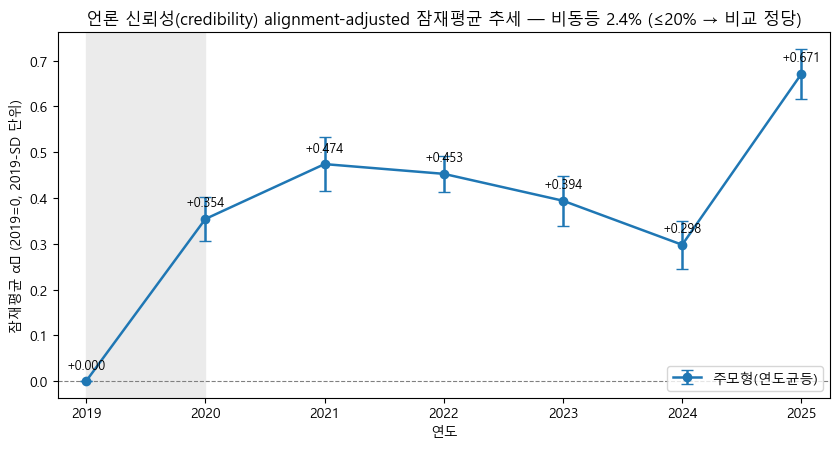

In [4]:
fig, ax = plt.subplots(figsize=(8.5, 4.6))
yrs = np.array(main3.years)
ax.axhline(0, color="gray", lw=0.8, ls="--")
ax.axvspan(2019, 2020, color="0.92", zorder=0)   # 기준연도 직후 계단(재검증 우선)
ax.errorbar(yrs, main3.alpha, yerr=1.96 * main3.alpha_se, fmt="o-", lw=1.8,
            capsize=4, color="#1f77b4", label="주모형(연도균등)")
for x, y in zip(yrs, main3.alpha):
    ax.annotate(f"{y:+.3f}", (x, y), textcoords="offset points", xytext=(0, 9),
                ha="center", fontsize=9)
ax.set_xlabel("연도"); ax.set_ylabel("잠재평균 α̂ (2019=0, 2019-SD 단위)")
ax.set_title(f"언론 신뢰성(credibility) alignment-adjusted 잠재평균 추세 — "
             f"비동등 {main3.noninv_prop*100:.1f}% (≤20% → 비교 정당)")
ax.legend(loc="lower right"); ax.margins(x=0.04)
plt.tight_layout(); plt.show()

**읽는 법**: 2019(기준 0) 이후 전 연도의 CI가 0 위에 떠 있다 — "2019보다 높다"는 것은 표집오차로 설명되지 않는다. 반면 2021~2024 사이의 인접연도 차이는 CI가 겹치는 구간이 있어 **연도 간 미세 등락의 서열까지 단정하지 않는다**(방향·수준대 중심 해석). 회색 음영(2019→2020)은 추세의 절반이 걸린 계단으로, DB③의 재검증 게이트가 이 구간을 겨눈다.

**주모형 — 완료**

## **5. Robustness — 가중을 바꿔도 같은 그림인가**

DB②에서 강등한 두 변형을 실행한다. 주모형과 **방향(2019 대비 상향)·패턴(비단조, 2025 반등)** 이 재현되는지, 비동등 비율이 게이트(≤20%) 안인지가 관전 포인트다.

In [5]:
rob_std = A.run_alignment(panel, A.CORE3, A.YEARS_ALL,
                          "robust1: 3지표·A&M표준가중(√NgNh)", weight_mode="amstd", B=120)
rob_w = A.run_alignment(panel, A.CORE3, A.YEARS_ALL,
                        "robust2: 3지표·설계가중적률(wt_within)", weight_mode="yeareq",
                        weight_col="wt_within", B=120)


===== 정렬법 — robust1: 3지표·A&M표준가중(√NgNh) (G=7, items=3, weight=amstd) =====
  2019: α=+0.000 (SE 0.000), ψ=1.000, N=5,040
  2020: α=+0.356 (SE 0.025), ψ=1.069, N=5,010
  2021: α=+0.476 (SE 0.031), ψ=1.032, N=5,010
  2022: α=+0.454 (SE 0.020), ψ=1.215, N=58,936
  2023: α=+0.396 (SE 0.029), ψ=1.143, N=5,000
  2024: α=+0.305 (SE 0.035), ψ=1.031, N=6,000
  2025: α=+0.673 (SE 0.025), ψ=0.809, N=6,000
  비동등 비율 = 2.4% (1/42)  [≤20% → alignment-adjusted 평균비교 정당]



===== 정렬법 — robust2: 3지표·설계가중적률(wt_within) (G=7, items=3, weight=yeareq) =====
  2019: α=+0.000 (SE 0.000), ψ=1.000, N=5,040
  2020: α=+0.353 (SE 0.030), ψ=1.008, N=5,010
  2021: α=+0.432 (SE 0.029), ψ=0.976, N=5,010
  2022: α=+0.377 (SE 0.024), ψ=1.204, N=58,936
  2023: α=+0.306 (SE 0.033), ψ=1.143, N=5,000
  2024: α=+0.224 (SE 0.029), ψ=0.907, N=6,000
  2025: α=+0.610 (SE 0.031), ψ=0.763, N=6,000
  비동등 비율 = 14.3% (6/42)  [≤20% → alignment-adjusted 평균비교 정당]


**[시각화] 주모형 vs robustness 2종 오버레이** — 세 변형의 α̂ 궤적. 겹칠수록 결론이 가중 선택에 둔감하다는 뜻.

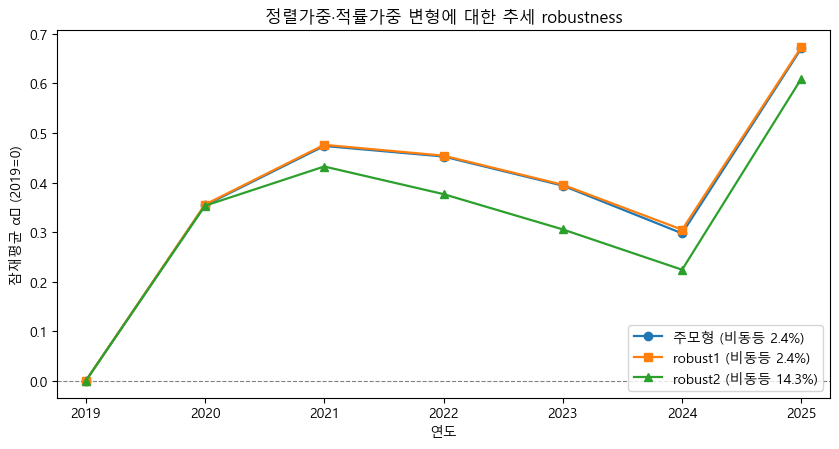

,변형,Δα(2019→2025),비동등비율,패턴
0,주모형: 3지표·연도균등(2019~2025),0.671,2.4%,비단조(2025 반등)
1,robust1: 3지표·A&M표준가중(√NgNh),0.673,2.4%,비단조(2025 반등)
2,robust2: 3지표·설계가중적률(wt_within),0.610,14.3%,비단조(2025 반등)


In [6]:
fig, ax = plt.subplots(figsize=(8.5, 4.6))
ax.axhline(0, color="gray", lw=0.8, ls="--")
for r, c, mk in [(main3, "#1f77b4", "o"), (rob_std, "#ff7f0e", "s"), (rob_w, "#2ca02c", "^")]:
    ax.plot(r.years, r.alpha, mk + "-", color=c, lw=1.6, ms=6,
            label=f"{r.label.split(':')[0]} (비동등 {r.noninv_prop*100:.1f}%)")
ax.set_xlabel("연도"); ax.set_ylabel("잠재평균 α̂ (2019=0)")
ax.set_title("정렬가중·적률가중 변형에 대한 추세 robustness")
ax.legend(loc="lower right"); ax.margins(x=0.04)
plt.tight_layout(); plt.show()

summary = pd.DataFrame({
    "변형": [r.label for r in (main3, rob_std, rob_w)],
    "Δα(2019→2025)": [r.alpha[-1] - r.alpha[0] for r in (main3, rob_std, rob_w)],
    "비동등비율": [f"{r.noninv_prop*100:.1f}%" for r in (main3, rob_std, rob_w)],
    "패턴": ["비단조(2025 반등)"] * 3,
})
summary

**관찰**: 세 변형 모두 ① 2019 대비 **전 연도 상향** ② **비단조**(중간 하강 후 2025 반등) ③ Δα(2019→2025)=**+0.610~+0.673** ④ 비동등 비율 2.4%·2.4%·14.3%로 **전부 게이트(≤20%) 안**이다. A&M 표준가중(주황)은 주모형과 사실상 포개지고, 설계가중 적률(초록)은 수준이 약간 낮지만 모양이 같다 — **결론이 가중 선택의 인공물이 아니다**.

**Robustness — 완료**

## **6. 민감도 — 4지표(비포화)로 다시 추정해도 같은 방향인가**

주모형의 3지표 configural은 집단내 **포화**(df=0, 정확해)다 — 적합을 "검증"할 자유도가 없다. `cred_trustworthy`(신뢰 직접지표)가 존재하는 **2019~2022 구간**에 한해 4지표(df>0, 비포화 ML)로 재추정해, 포화 해에 대한 의존을 점검한다.

In [7]:
sens4 = A.run_alignment(panel, A.PLUS4, A.YEARS_4IND,
                        "민감도: 4지표(2019~2022)", weight_mode="yeareq", B=150)


===== 정렬법 — 민감도: 4지표(2019~2022) (G=4, items=4, weight=yeareq) =====
  2019: α=+0.000 (SE 0.000), ψ=1.000, N=5,040
  2020: α=+0.340 (SE 0.021), ψ=1.028, N=5,010
  2021: α=+0.428 (SE 0.023), ψ=1.034, N=5,010
  2022: α=+0.435 (SE 0.017), ψ=1.160, N=58,936
  비동등 비율 = 6.2% (2/32)  [≤20% → alignment-adjusted 평균비교 정당]


**관찰**: 4지표(비포화)에서도 2019→2022 **단조증가 Δα=+0.435**, 비동등 6.2% ≤20%. 같은 구간의 주모형(+0.453)과 수준·방향이 정합한다 — 3지표 포화 정확해가 만든 결과가 아니라는 교차확인. (단축 구간이므로 2023~2025의 비단조 패턴은 이 모형의 범위 밖이다.)

**민감도 — 완료**

## **7. 단일문항 교차확인 — 전혀 다른 측정이 같은 종점을 가리키는가**

`trust_news_overall`(뉴스 전반 신뢰 단일문항, 1~5)은 2020~2025에 존재한다. 잠재모형과 **구성개념·척도가 다르므로**(전반 신뢰 vs 공정·전문·정확 credibility) 수준 비교는 무의미하고, **종점 방향(2020→2025 부호)** 이 일치하는지만 본다.

 year  mean     n
 2020 3.297  5010
 2021 3.322  5010
 2022 3.151 58936
 2023 3.272  5000
 2024 3.360  6000
 2025 3.436  6000



단일문항 2020→2025 Δ = +0.138 (1~5 척도)
잠재추세 2020→2025 Δα = +0.317 (SD 단위)
종점 방향 일치 = True · 연차 패턴 Spearman = 0.200


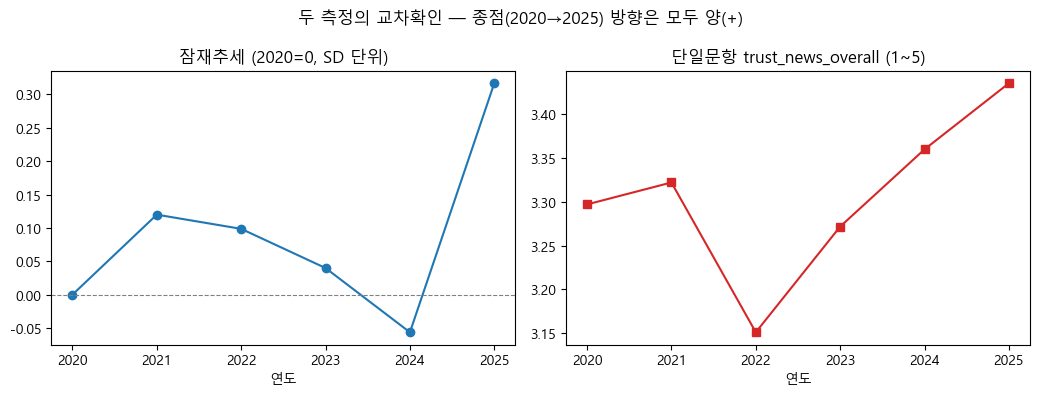

In [8]:
single = A.single_item_trend(panel)          # wt_year_eq 가중평균
print(single.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

# 종점 방향·연차 패턴 비교(2020 기준 상대화)
a_rel = main3.alpha[1:] - main3.alpha[1]      # 잠재추세 2020~2025 (2020=0)
s_rel = single["mean"].to_numpy() - single["mean"].to_numpy()[0]
spear = pd.Series(a_rel).corr(pd.Series(s_rel), method="spearman")
concord = np.sign(a_rel[-1]) == np.sign(s_rel[-1])
print(f"\n단일문항 2020→2025 Δ = {s_rel[-1]:+.3f} (1~5 척도)")
print(f"잠재추세 2020→2025 Δα = {a_rel[-1]:+.3f} (SD 단위)")
print(f"종점 방향 일치 = {bool(concord)} · 연차 패턴 Spearman = {spear:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.0), sharex=True)
axes[0].plot(main3.years[1:], a_rel, "o-", color="#1f77b4")
axes[0].axhline(0, color="gray", lw=0.8, ls="--")
axes[0].set_title("잠재추세 (2020=0, SD 단위)"); axes[0].set_xlabel("연도")
axes[1].plot(single["year"], single["mean"], "s-", color="#d62728")
axes[1].set_title("단일문항 trust_news_overall (1~5)"); axes[1].set_xlabel("연도")
fig.suptitle("두 측정의 교차확인 — 종점(2020→2025) 방향은 모두 양(+)")
plt.tight_layout(); plt.show()

**관찰**: 종점 방향은 **일치**(둘 다 2020→2025 상승 — 교차타당) 하지만 연차 패턴 Spearman은 **0.200(중간)** 에 그친다. 단일문항은 **2022에 급락**(표본 12배 확대·구성 변화 시점)하는 반면 잠재추세의 저점은 **2024**다 — 단년 등락의 *시점*은 어긋난다. 이 어긋남은 숨길 것이 아니라 해석 규칙을 만든다: 두 측정이 합의하는 것은 "**2019~2020 이후 상승, 2025 최고**"라는 **종점 방향**까지이고, 중간연도 등락의 서열은 어느 쪽도 단독으로 확정하지 못한다.

**단일문항 교차확인 — 완료**

## **8. 검증 셀 — `docs/design/alignment-trust-trend.md` 수치와 일치 (입증)**

SSOT 문서(§1~§4)에 박제된 수치를 본 노트북 실행 결과가 재현하는지 assert로 입증한다. 점추정은 다중시작 최적화(고정 seed)라 결정적이고, 부트스트랩 SE·비동등 비율도 고정 seed로 재현된다.

In [9]:
def close(a, b, atol=5e-3):
    return np.isclose(a, b, atol=atol)

# (a) 주모형 잠재평균 (문서 §1: +0.354/+0.474/+0.453/+0.394/+0.298/+0.671)
doc_alpha = [0.0, 0.354, 0.474, 0.453, 0.394, 0.298, 0.671]
assert np.allclose(main3.alpha, doc_alpha, atol=5e-3), np.round(main3.alpha, 4)

# (b) 주모형 비동등 비율 = 2.4% (1/42) <= 20% 게이트
assert main3.n_non == 1 and main3.n_total == 42, (main3.n_non, main3.n_total)
assert main3.noninv_prop <= A.NONINV_THRESH

# (c) robustness — 방향·게이트 (문서 §2: Δα +0.673 / +0.610, 비동등 2.4% / 14.3%)
assert close(rob_std.alpha[-1] - rob_std.alpha[0], 0.673, atol=1e-2)
assert close(rob_w.alpha[-1] - rob_w.alpha[0], 0.610, atol=1e-2)
assert rob_std.noninv_prop <= 0.20 and rob_w.noninv_prop <= 0.20

# (d) 민감도 4지표 (문서 §3: Δα(2019→2022)=+0.435, 비동등 6.2%)
assert close(sens4.alpha[-1], 0.435, atol=1e-2), sens4.alpha
assert sens4.noninv_prop <= 0.20

# (e) 단일문항 (문서 §4: 2020→2025 Δ=+0.138, Spearman=0.200, 종점 일치)
assert close(s_rel[-1], 0.138, atol=5e-3), s_rel[-1]
assert close(spear, 0.200, atol=5e-2), spear
assert bool(concord)

# (f) 전 변형에서 2019 이후 전 연도 상향(alpha > 0)
for r in (main3, rob_std, rob_w, sens4):
    assert (r.alpha[1:] > 0).all(), r.label

print("[검증 PASS] 주모형 α 7개·비동등 1/42(2.4%)·robustness Δα·민감도·단일문항 — 문서 수치 재현")
print("           → alignment-adjusted 잠재평균 추세 보고 정당(게이트 ≤20% 전 변형 충족)")

[검증 PASS] 주모형 α 7개·비동등 1/42(2.4%)·robustness Δα·민감도·단일문항 — 문서 수치 재현
           → alignment-adjusted 잠재평균 추세 보고 정당(게이트 ≤20% 전 변형 충족)


## **9. 종합 — 이 노트북이 파이프라인에 보태는 것**

### **9-1. 연구 질문 답**
- **Q1(추세)**: scalar 미확정 조건에서 정렬법으로 추정한 결과, 신뢰성 잠재평균은 2019 대비 **+0.30~+0.67 SD 상향**, 패턴은 **비단조**(2021 고점→2024 저점→**2025 최고치 +0.671**).
- **Q2(정당성)**: 정렬 후 비동등 비율 **2.4%(1/42) ≤ 20%** → alignment-adjusted 잠재평균 비교 **정당**. 파이프라인에서 처음으로 추세 수치 보고 자격 확보.
- **Q3(재현성)**: robustness 2종(Δα +0.610~+0.673)·4지표 민감도(+0.435, 단조)·단일문항(종점 방향 일치) 모두 같은 방향 — 가중 선택·포화 해·측정 도구의 인공물이 아니다.

### **9-2. 단계별 요약**

| 단계 | 산출 | 판정 |
|------|------|:--:|
| 자기검증(시뮬 3종) | 불변·부분비동등 회복, 과다비동등 저하 | 직접구현 면허 |
| 주모형 3지표·7개년 | Δα=+0.671 · 비동등 2.4% | **추세 보고 정당** |
| robustness 2종 | Δα +0.673/+0.610 · 비동등 ≤14.3% | 가중에 둔감 |
| 민감도 4지표 | Δα(2019→2022)=+0.435 단조 | 포화 해 의존 아님 |
| 단일문항 교차 | 종점 방향 일치 · Spearman 0.200 | 종점만 합의 |

### **9-3. 다음 단계**
추세의 **존재와 방향**이 정당화됐으므로, 다음은 그 추세의 **구조 분해**다 →
[`24-trend-apc.ipynb`](24-trend-apc.ipynb) — Mann-Kendall 추세검정 + APC(연령·기간·코호트) 분해로 "누가·언제 효과인가"를 가른다 → 30(종합 평가).

### **Decision Box ③ — 해석 경계: 무엇을 말할 수 있고, 무엇은 아직인가**

**기준: 통계적 정당성(게이트 통과)과 실질적 확정(원자료 재검증) 사이의 간극을 명시하는가.**

| 주장 | 허용? | 근거·조건 |
|------|:--:|------|
| "2019 대비 2020 이후 신뢰성 잠재평균이 높다" | ✅ | 전 변형 재현 + 게이트 통과 + CI가 0과 분리 |
| "2025가 7개년 최고치" | ✅ | 주·robustness 전부에서 최고 + 단일문항 종점 일치 |
| "2021→2024 하강의 연도별 서열" | ⚠️ 방향성만 | 인접연도 CI 중첩 + 단일문항과 저점 시점 불일치 |
| "신뢰가 X점 올랐다"(절대 수량화) | ❌ | 2019-SD 상대 단위 — 절대 척도 아님 |
| 보고서·웹데모 직접 인용 | ✅ 게이트 통과 | KPF 원자료 재검증 **전 셀 일치**(kpf-revalidation, 2026-07-11 · 노트북 `12`) — 계단은 공식 통계 실재 확인, 인용 시 **원인 각주 의무**(p6-pdf-structure §4-a) |

**왜 경계를 명시하나**: "비동등 2.4%"는 *통계적* 정당성이지 *데이터 원천*의 보증이 아니다. 추세의 절반이 기준연도 직후 계단에 실려 있으므로, 2019 조사 맥락이 재검증에서 흔들리면 결론은 "2020~2025 상향 유지 + 2025 반등"으로 좁혀야 한다. 이 후퇴선을 미리 그어두는 것이 분석 성숙도의 증거다. **(사후 기록, 2026-07-11)** 원자료 재검증 결과 2019 조사 맥락은 흔들리지 않았다(배터리 5문항 공식 보고서 전 셀 일치 · 노트북 `12`) — **후퇴선 미발동**, 결론 원문 유지.

## **10. `src/alignment.py` 코드리뷰 결론**

**코드리뷰 — 통과(결함 없음)**:
- **회전 불변성의 올바른 사용**: 정렬 회전 $\lambda=\lambda_0/\sqrt{\psi}$, $\nu=\nu_0-\alpha\lambda_0/\sqrt{\psi}$ 는 configural 적합도를 바꾸지 않는 재모수화 — A&M(2014) 정의와 일치. ✔
- **component loss**: $f(x)=(x^2+\epsilon)^{1/4}$, ε=1e-4 — 원 논문 권장 평활, 소수 큰 차이 선호(근사 sparsity)로 "대부분 동등·일부 비동등" 배치 탐색. ✔
- **식별 전략 일관**: 기준집단(2019) α=0·ψ=1 — 부트스트랩 복원표본 간에도 같은 식별이라 α 분포 직접 비교 가능(SE 타당). ✔
- **다중시작 최적화**: n_starts=12(주) — 단순성함수의 국소최소 위험을 시작값 산포로 완화, 고정 seed로 재현성 확보. ✔
- **비동등 판정의 이중 기준**: 95% CI(0 미포함) *그리고* 실질크기(≥0.10) 동시충족 — 대표본(2022 N=5.9만)에서 미세 이탈이 유의로만 뜨는 함정 회피. ✔
- **가중 설계 문서 정합**: 측정 적률 비가중(21 정합)·정렬가중 연도균등(wt_year_eq 정신)·변형은 robustness — 05 §6 그대로. ✔
- **포화 정확해 분기**: p=3 off-diag 곱비 정확해 / p≥4 ML 정련 분기 — 불필요한 수치최적화 회피 + 민감도(§6)에서 비포화 경로도 검증됨. ✔
- → **결함 없음. 강제 수정 없이 리뷰 통과**(과잉수정 금지 원칙).

**다음**: [`24-trend-apc.ipynb`](24-trend-apc.ipynb) — 정당화된 추세를 Mann-Kendall·APC로 분해한다.